In [118]:
! pip install Pillow


[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
from scipy import signal
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter
import math
from PIL import Image, ImageDraw

## 1.グリッドの定義と描画

### 入力
- フロアマップの幅[px] : 2,837px ` map_width_px (int)`
- フロアマップの高さ[px]:  3,742px `map_height_px (int)`
- グリッドの一辺の長さ[px] : 30px `grid_size_px (int)`

### 出力
- 横方向のグリッド数 95 `num_grids_x`
- 縦方向のグリッド数 125 `num_grids_y`

### アルゴリズム
フロアマップの寸法とグリッドサイズから、横方向と縦方向にいくつのグリッドができるかを計算
- 横方向のグリッド数： $N_x = \lceil W / G \rceil = \lceil 2837 / 30 \rceil = \lceil 94.56... \rceil = 95$
- 縦方向のグリッド数： $N_y = \lceil H / G \rceil = \lceil 3742 / 30 \rceil = \lceil 124.73... \rceil = 125$



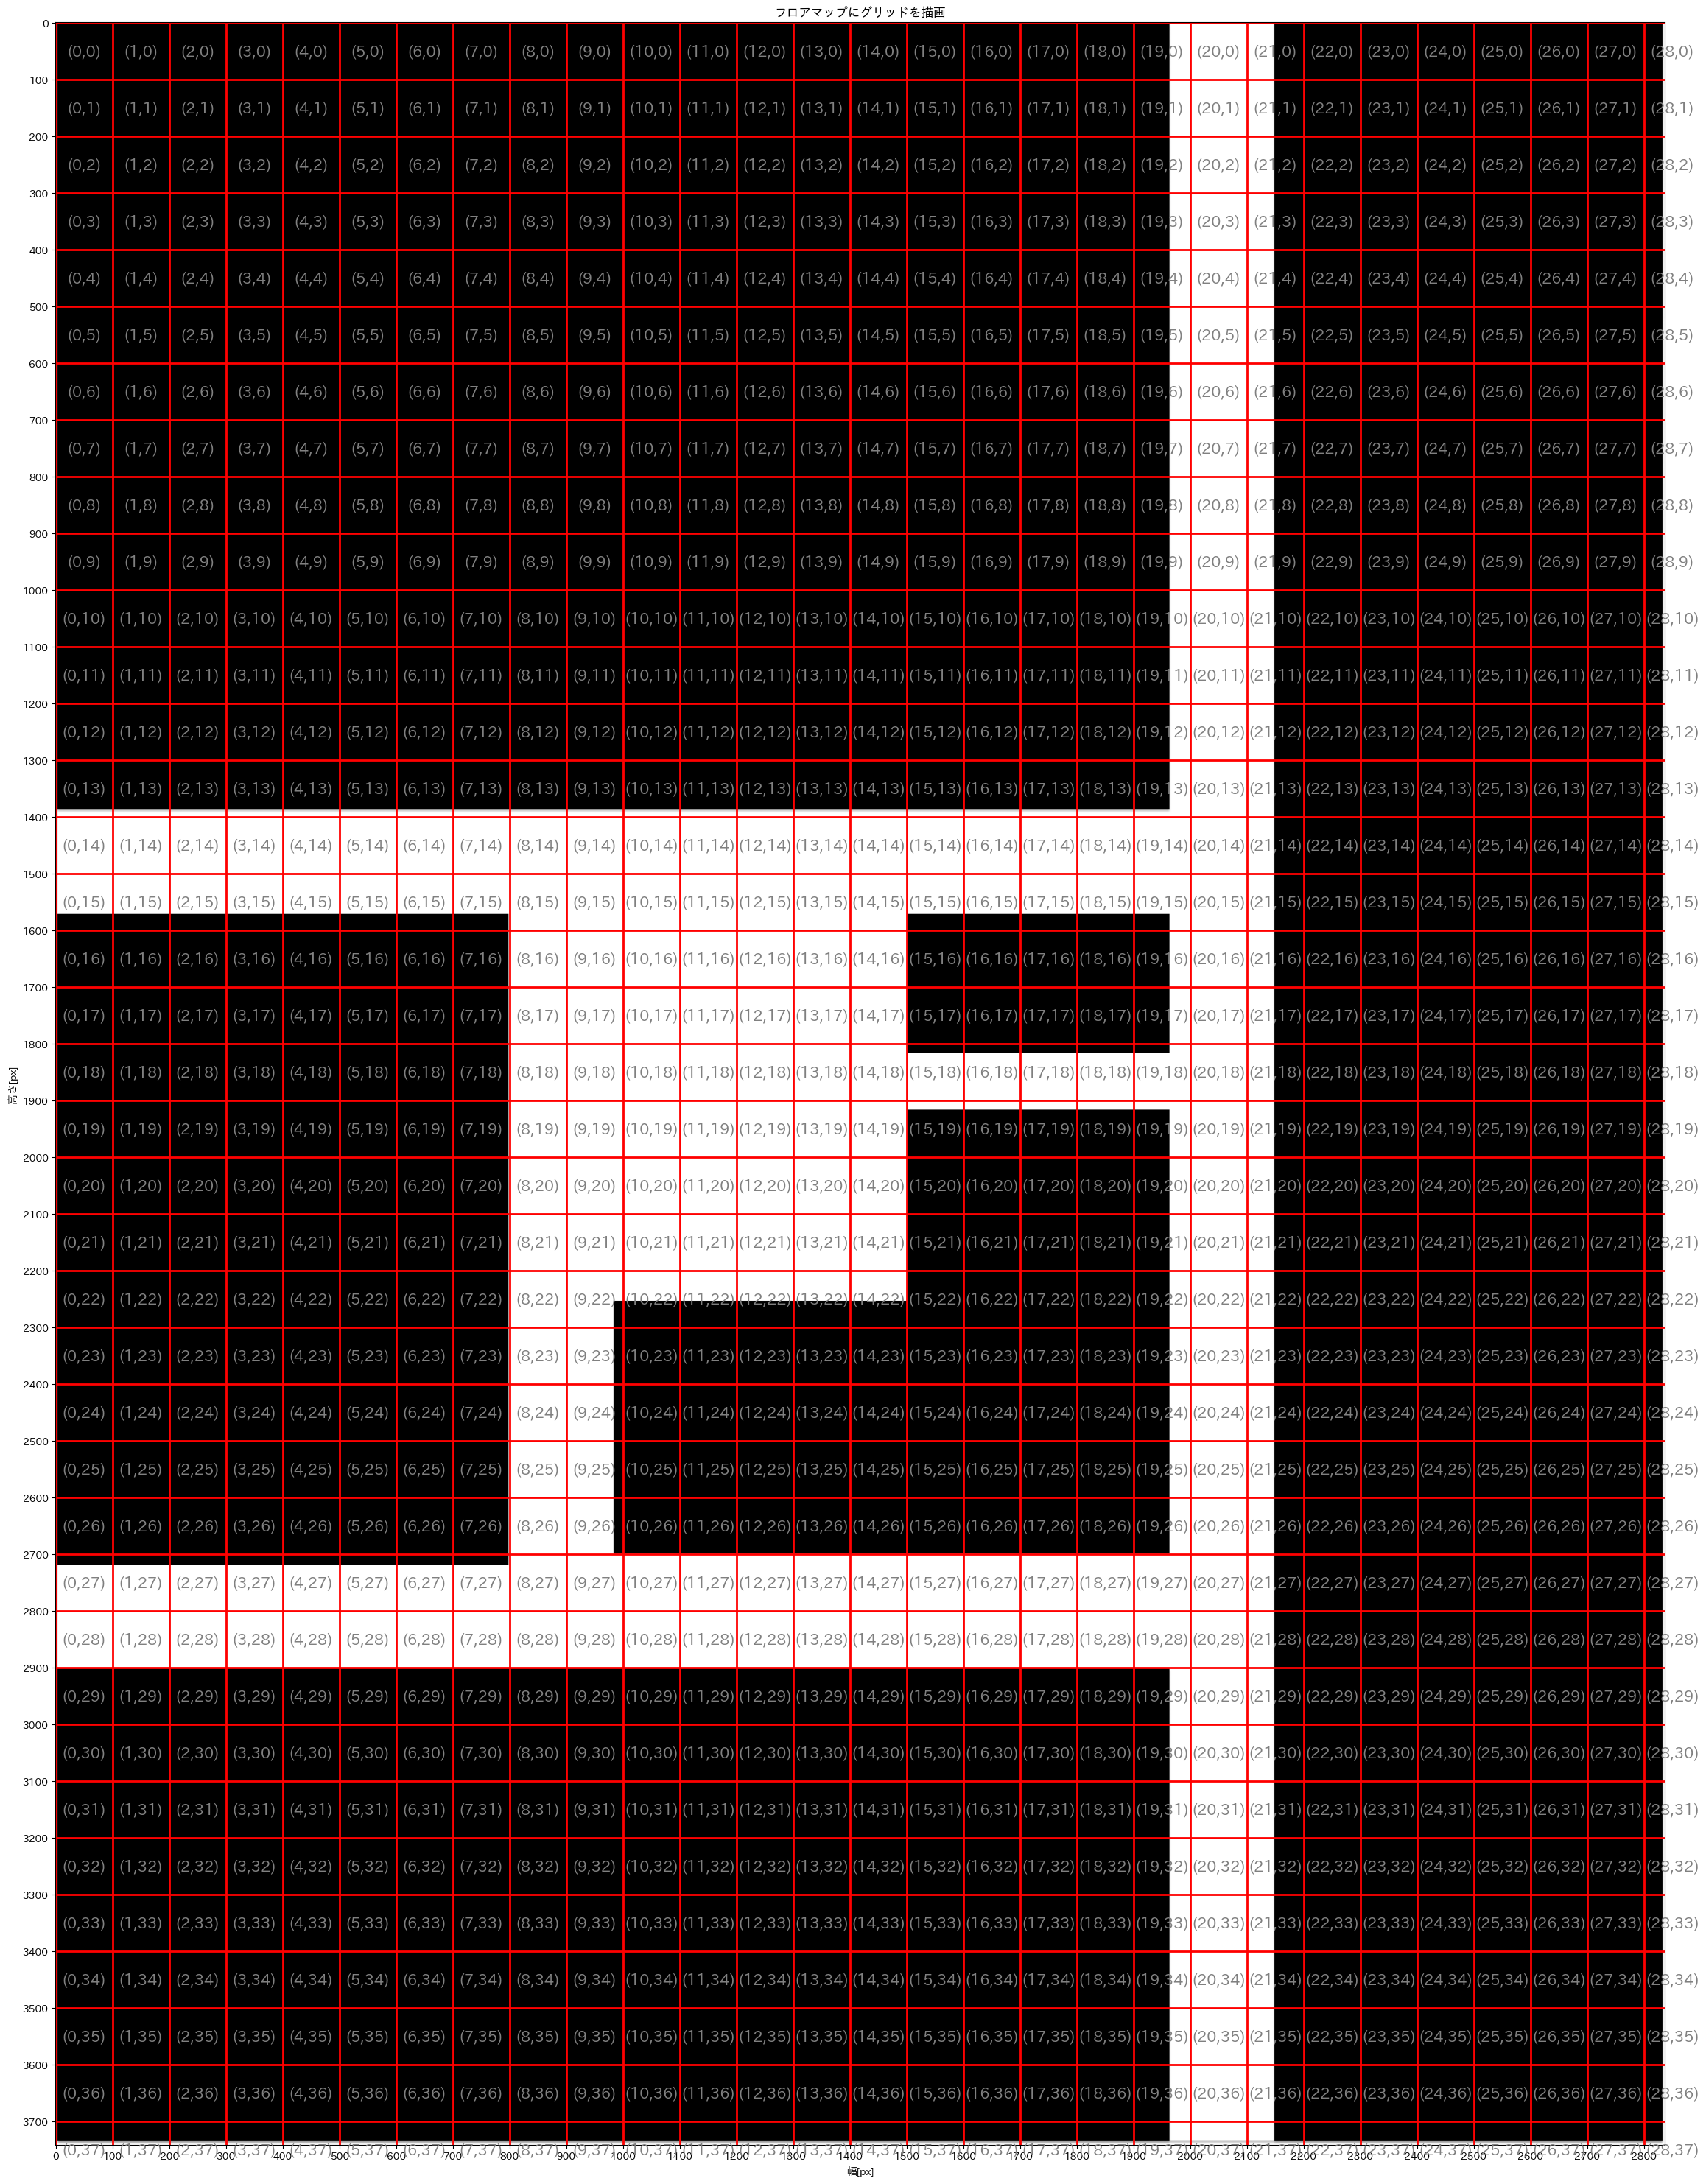

--- グリッド定義 ---
フロアマップの幅: 2837 px
フロアマップの高さ: 3742 px
グリッドサイズ: 100 px
実際のサイズ: 1m
横方向のグリッド数 (Nx): 29
縦方向のグリッド数 (Ny): 38
--------------------


In [5]:
# 1. グリッドの定義
# 提供されたフロアマップの寸法を使用
from matplotlib import ticker


map_width = 2837
map_height = 3742
# 提案されたグリッドサイズ
grid_size = 100 


num_grids_x = math.ceil(map_width / grid_size)
num_grids_y = math.ceil(map_height / grid_size)

img = Image.open("../../docs/floorMap/building＝14,floor=5_freeSpace.png")

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img)

# グリッドの間隔を設定
# MultipleLocatorを使って、指定したgrid_sizeごとにグリッド線を表示
ax.xaxis.set_major_locator(ticker.MultipleLocator(grid_size))
ax.yaxis.set_major_locator(ticker.MultipleLocator(grid_size))


# グリッドを表示
ax.grid(which='major', color='red', linestyle='-', linewidth=2)


# 4. 各グリッドにIDを割り振って描画
grid_data = []
for y in range(num_grids_y):
    for x in range(num_grids_x):
        # グリッドの中心座標を計算
        center_x = x * grid_size + grid_size / 2
        center_y = y * grid_size + grid_size / 2

        grid_id_tuple = (x, y)
        ax.text(center_x, center_y, f"({x},{y})", color='gray',
                ha='center', va='center', fontsize=15)

        # グリッドの情報を辞書として保存
        grid_info = {
            'id': grid_id_tuple,
            'x_min': x * grid_size,
            'y_min': y * grid_size,
            'x_max': (x + 1) * grid_size,
            'y_max': (y + 1) * grid_size
        }
        grid_data.append(grid_info)


# 画像を表示
plt.title('フロアマップにグリッドを描画')
plt.xlabel('幅[px]')
plt.ylabel('高さ[px]')
fig.savefig("output/gridFloorMap.png", bbox_inches='tight', dpi=100)
plt.show()



print(f"--- グリッド定義 ---")
print(f"フロアマップの幅: {map_width} px")
print(f"フロアマップの高さ: {map_height} px")
print(f"グリッドサイズ: {grid_size} px")
print(f"実際のサイズ: 1m")
print(f"横方向のグリッド数 (Nx): {num_grids_x}")
print(f"縦方向のグリッド数 (Ny): {num_grids_y}")
print("-" * 20)


# 歩行軌跡をフロアマップにマッピング

## Step.0 軌跡データの取得

In [121]:
#stay=trueの軌跡を赤くそれ以外を青く表示

     time         x         y     speed   stay
0    7.25 -0.051118  0.411710       NaN  False
1    7.50 -0.058507  0.599842  0.753107  False
2    7.75 -0.065896  0.787973  0.753107  False
3    8.00 -0.017568  0.961232  0.719489  False
4    8.25  0.033400  1.133785  0.719694  False
5    8.50  0.050284  1.312206  0.716873  False
6    8.75  0.054663  1.492780  0.722508  False
7    9.00  0.088399  1.665715  0.704780  False
8    9.25  0.149555  1.831516  0.706880  False
9    9.50  0.207363  1.999262  0.709709  False
10   9.75  0.255316  2.172732  0.719905  False
11  10.00  0.301818  2.341204  0.699085  False
12  10.25  0.303077  2.353879  0.050950   True
13  10.50  0.304335  2.366554  0.050950   True
14  10.75  0.305594  2.379229  0.050950   True
15  11.00  0.306853  2.391904  0.050950   True
16  11.25  0.308111  2.404579  0.050950   True
17  11.50  0.309370  2.417254  0.050950   True
18  11.75  0.310629  2.429929  0.050950   True
19  12.00  0.311888  2.442605  0.050950   True
20  12.25  0.

<Figure size 640x480 with 0 Axes>

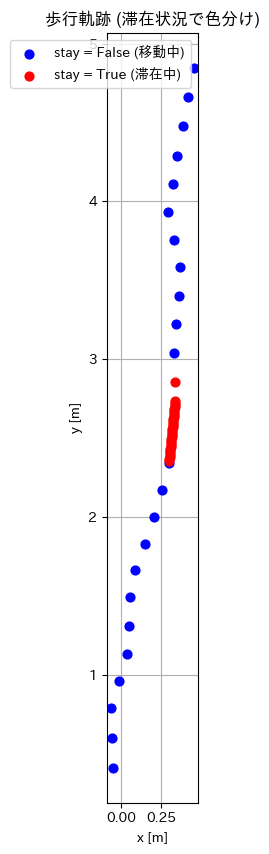

In [ ]:
# データの読み込み
trajectory_file_path = "./data/threshold_trajectory_data.csv"

df_trajectory = pd.read_csv(trajectory_file_path)


plt.subplots_adjust(hspace=0.3)
fig = plt.figure(figsize=(10, 10))

print(df_trajectory)
# stay=True と stay=False のデータに分割
stay_true = df_trajectory[df_trajectory['stay'] == True]
stay_false = df_trajectory[df_trajectory['stay'] == False]


plt.scatter(stay_false['x'], stay_false['y'], c='blue', s=40, label='stay = False (移動中)', zorder=2)
plt.scatter(stay_true['x'], stay_true['y'], c='red', s=40, label='stay = True (滞在中)', zorder=3)


# # 補間された軌跡を描画
# df_trajectory['x'], df_trajectory['y']
# plt.colorbar(plt.scatter(x, y,c=time,cmap='rainbow',s=40, label=f'推定軌跡', zorder=2))

plt.gca().set_aspect('equal', adjustable='box')
plt.title('歩行軌跡 (滞在状況で色分け)')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid(True)
plt.legend()  # 凡例を表示

plt.show()

## Step.1 スケール（縮尺）の補正

In [123]:
# --- パラメータ定義 ---
estimated_distance = 5.0
correct_distance = 5.0

# 変換計算
# 1. スケール補正係数と最終的なスケールを計算
scale_correction = correct_distance / estimated_distance
final_scale = 100 * scale_correction

# 4. 軌跡データに変換を適用
df_trajectory['x_scaled'] = df_trajectory['x'] * final_scale
df_trajectory['y_scaled'] = df_trajectory['y'] * final_scale

print(df_trajectory)


     time         x         y     speed   stay   x_scaled    y_scaled
0    7.25 -0.051118  0.411710       NaN  False  -5.111838   41.171019
1    7.50 -0.058507  0.599842  0.753107  False  -5.850730   59.984178
2    7.75 -0.065896  0.787973  0.753107  False  -6.589622   78.797337
3    8.00 -0.017568  0.961232  0.719489  False  -1.756849   96.123180
4    8.25  0.033400  1.133785  0.719694  False   3.340016  113.378525
5    8.50  0.050284  1.312206  0.716873  False   5.028430  131.220631
6    8.75  0.054663  1.492780  0.722508  False   5.466269  149.278021
7    9.00  0.088399  1.665715  0.704780  False   8.839922  166.571532
8    9.25  0.149555  1.831516  0.706880  False  14.955534  183.151604
9    9.50  0.207363  1.999262  0.709709  False  20.736316  199.926181
10   9.75  0.255316  2.172732  0.719905  False  25.531638  217.273222
11  10.00  0.301818  2.341204  0.699085  False  30.181789  234.120360
12  10.25  0.303077  2.353879  0.050950   True  30.307660  235.387873
13  10.50  0.304335 

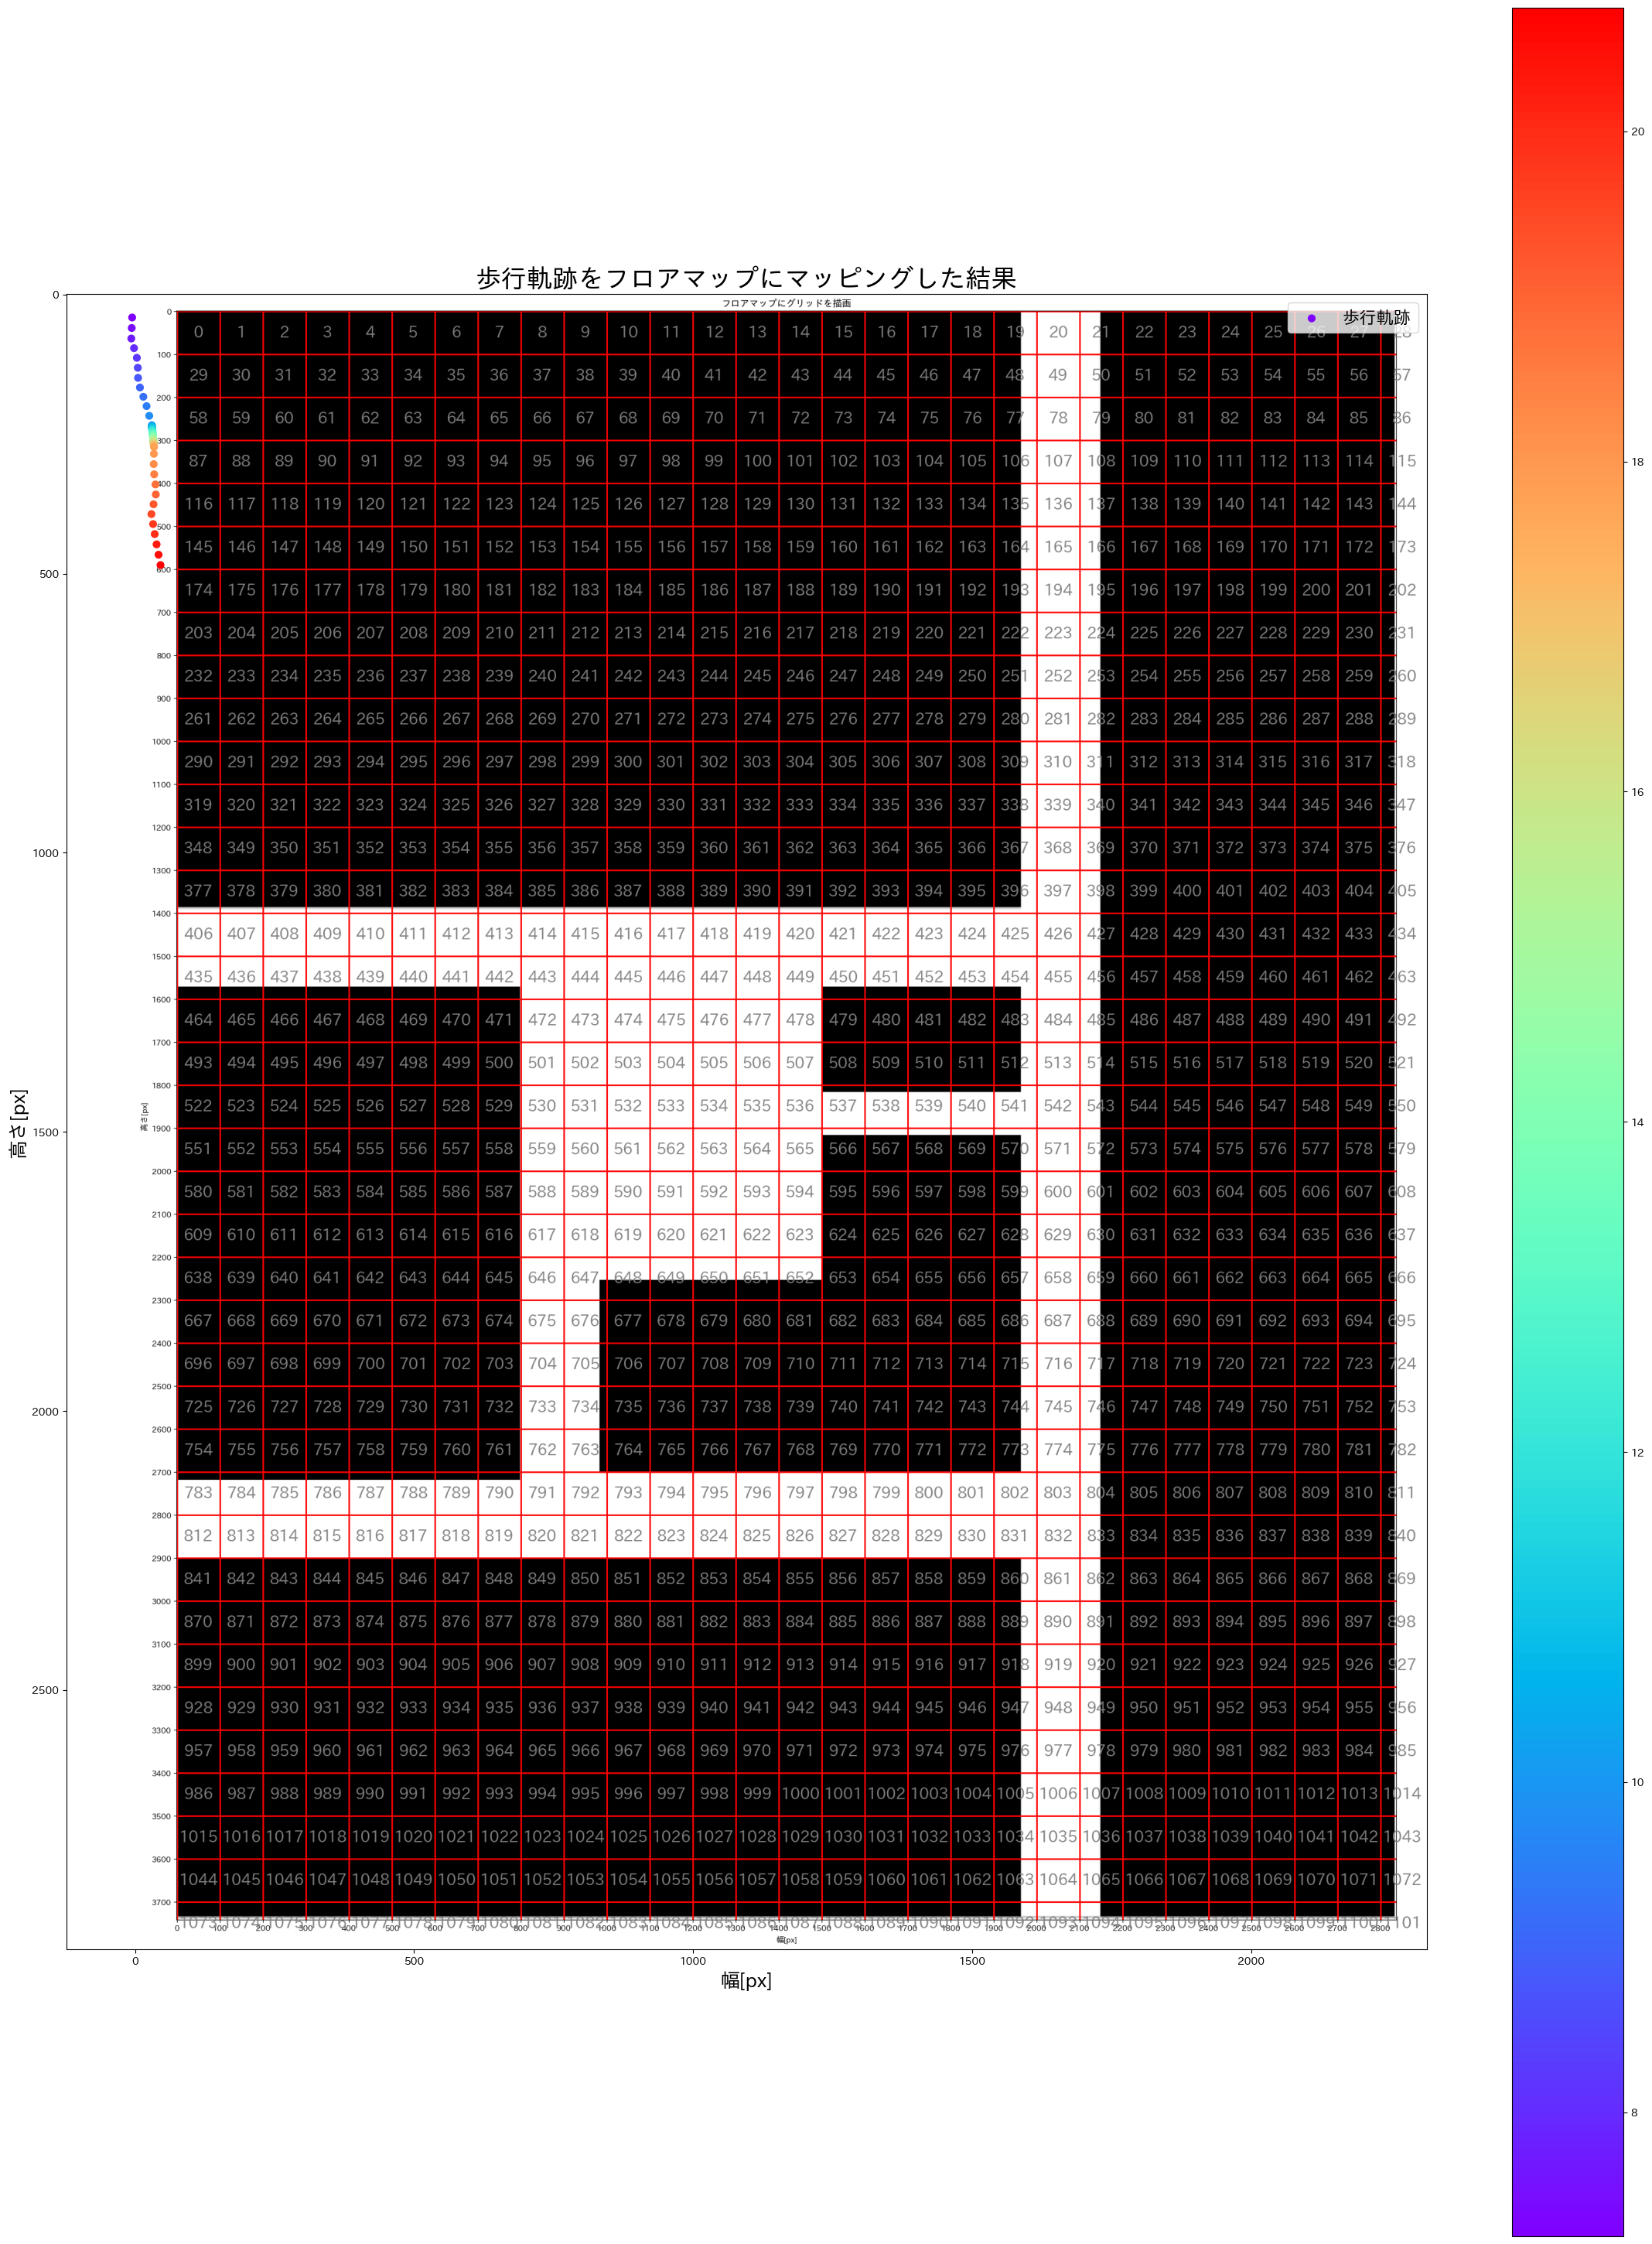

In [124]:
# グリッド付きフロアマップ画像を読み込み
img_grid = Image.open("output/gridFloorMap.png")

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img_grid)

# 変換後の軌跡をプロット
plt.colorbar(plt.scatter(df_trajectory['x_scaled'], df_trajectory['y_scaled'],c=time,cmap='rainbow',s=40, label=f'歩行軌跡', zorder=2))
# グラフの装飾
plt.title('歩行軌跡をフロアマップにマッピングした結果', fontsize=24)
plt.xlabel('幅[px]', fontsize=18)
plt.ylabel('高さ[px]', fontsize=18)
plt.legend(fontsize=16)
plt.show()


## Step.2 初期位置,初期方向の指定(座標変換)
初期位置の決定: 軌跡の開始点 `(0, 0)` がフロアマップ上のどこに対応するのかを決める
初期方向の決定: 軌跡がどの方向を向いているかを合わせる


In [125]:
#----パラメータ定義-------
# （例: -90度は時計回りに90度回転）
correct_angle = 180.0

 # 度数法からラジアンに変換
angle_rad = np.deg2rad(correct_angle)
cos_theta = np.cos(angle_rad)
sin_theta = np.sin(angle_rad)
    

# 計算結果を新しい変数(new_x, new_y)に格納し、元の変数を上書きしないようにします
df_trajectory['x_rotated']=  df_trajectory['x_scaled']* cos_theta - df_trajectory['y_scaled'] * sin_theta
df_trajectory['y_rotated'] = df_trajectory['x_scaled']* sin_theta + df_trajectory['y_scaled'] * cos_theta



     time         x         y     speed   stay   x_scaled    y_scaled  \
0    7.25 -0.051118  0.411710       NaN  False  -5.111838   41.171019   
1    7.50 -0.058507  0.599842  0.753107  False  -5.850730   59.984178   
2    7.75 -0.065896  0.787973  0.753107  False  -6.589622   78.797337   
3    8.00 -0.017568  0.961232  0.719489  False  -1.756849   96.123180   
4    8.25  0.033400  1.133785  0.719694  False   3.340016  113.378525   
5    8.50  0.050284  1.312206  0.716873  False   5.028430  131.220631   
6    8.75  0.054663  1.492780  0.722508  False   5.466269  149.278021   
7    9.00  0.088399  1.665715  0.704780  False   8.839922  166.571532   
8    9.25  0.149555  1.831516  0.706880  False  14.955534  183.151604   
9    9.50  0.207363  1.999262  0.709709  False  20.736316  199.926181   
10   9.75  0.255316  2.172732  0.719905  False  25.531638  217.273222   
11  10.00  0.301818  2.341204  0.699085  False  30.181789  234.120360   
12  10.25  0.303077  2.353879  0.050950   True  30.

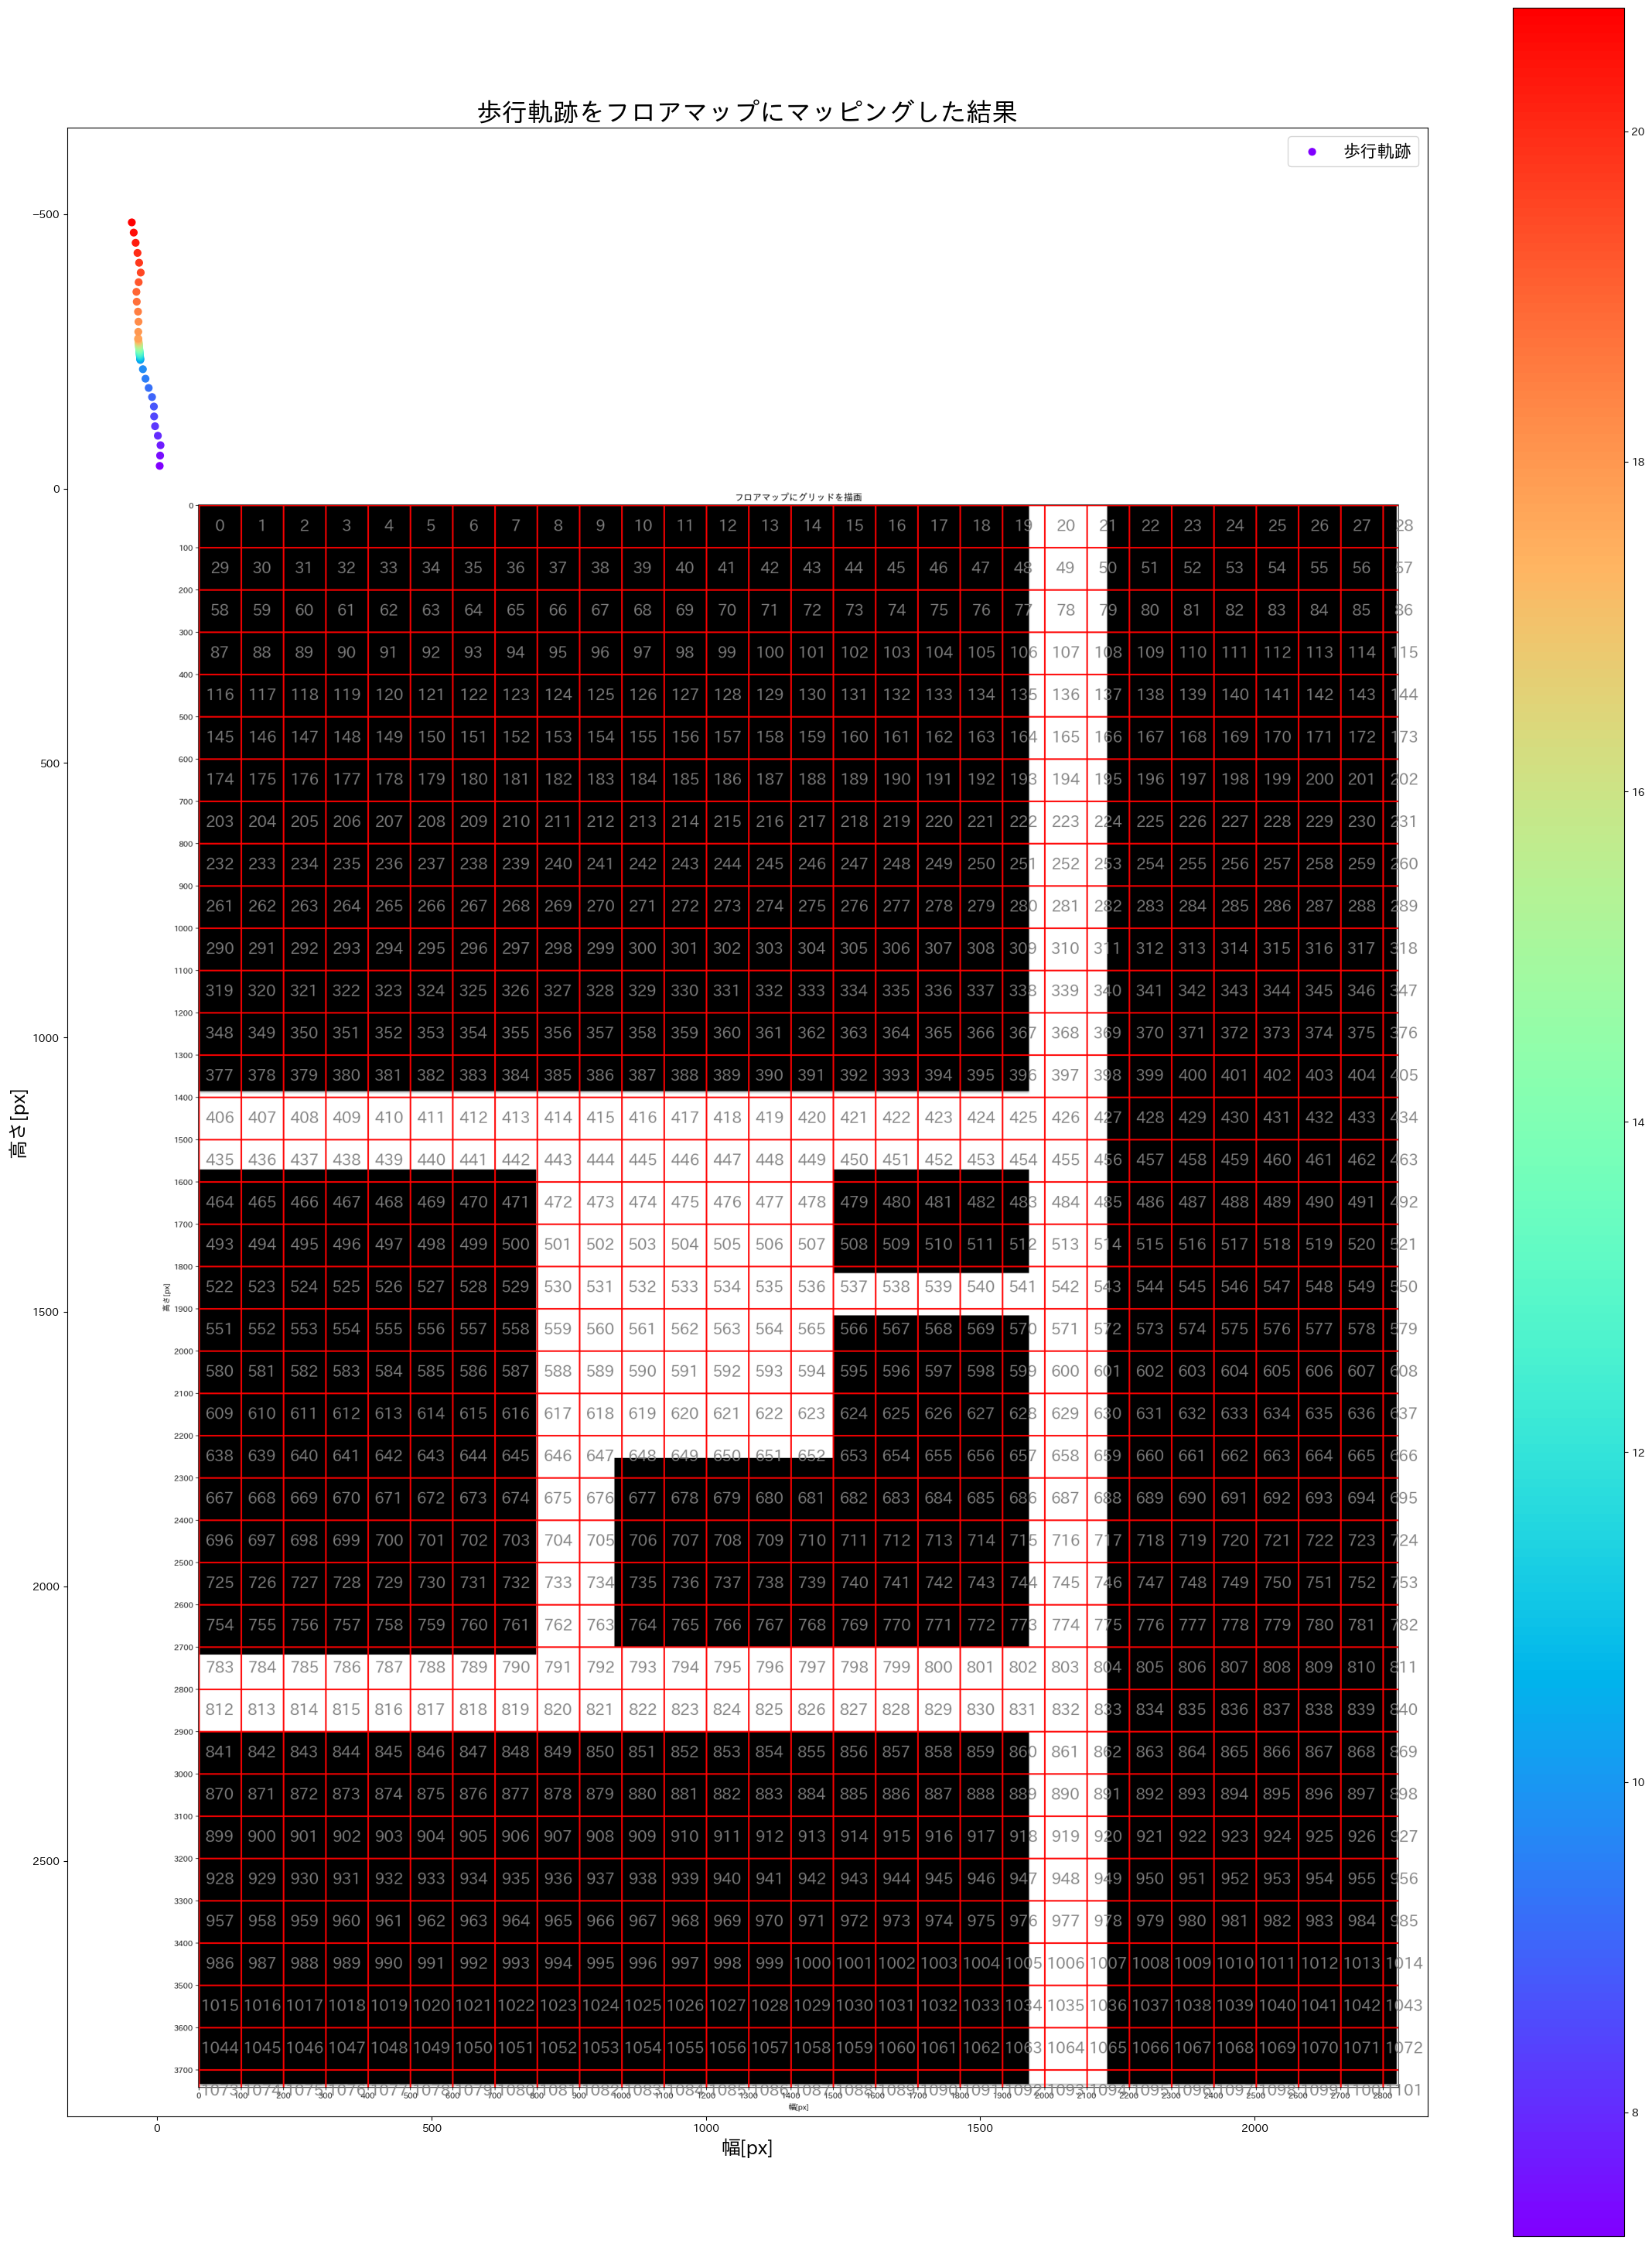

In [166]:
# グリッド付きフロアマップ画像を読み込み
img_grid = Image.open("output/gridFloorMap.png")

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img_grid)

print(df_trajectory)
# 変換後の軌跡をプロット
plt.colorbar(plt.scatter(df_trajectory['x_rotated'], df_trajectory['y_rotated'],c=time,cmap='rainbow',s=40, label=f'歩行軌跡', zorder=2))

# グラフの装飾
plt.title('歩行軌跡をフロアマップにマッピングした結果', fontsize=24)
plt.xlabel('幅[px]', fontsize=18)
plt.ylabel('高さ[px]', fontsize=18)
plt.legend(fontsize=16)
plt.show()


In [168]:
# 3. 平行移動量（オフセット）を計算
initial_position = 504

start_grid_info = next(item for item in grid_data if item["id"] == initial_position)
offset_x = start_grid_info['x_min'] + grid_size / 2
offset_y = start_grid_info['y_min'] + grid_size / 2

# 3. 平行移動を適用
df_trajectory['x_final'] = df_trajectory['x_rotated'] + offset_x
df_trajectory['y_final'] = df_trajectory['y_rotated'] + offset_y


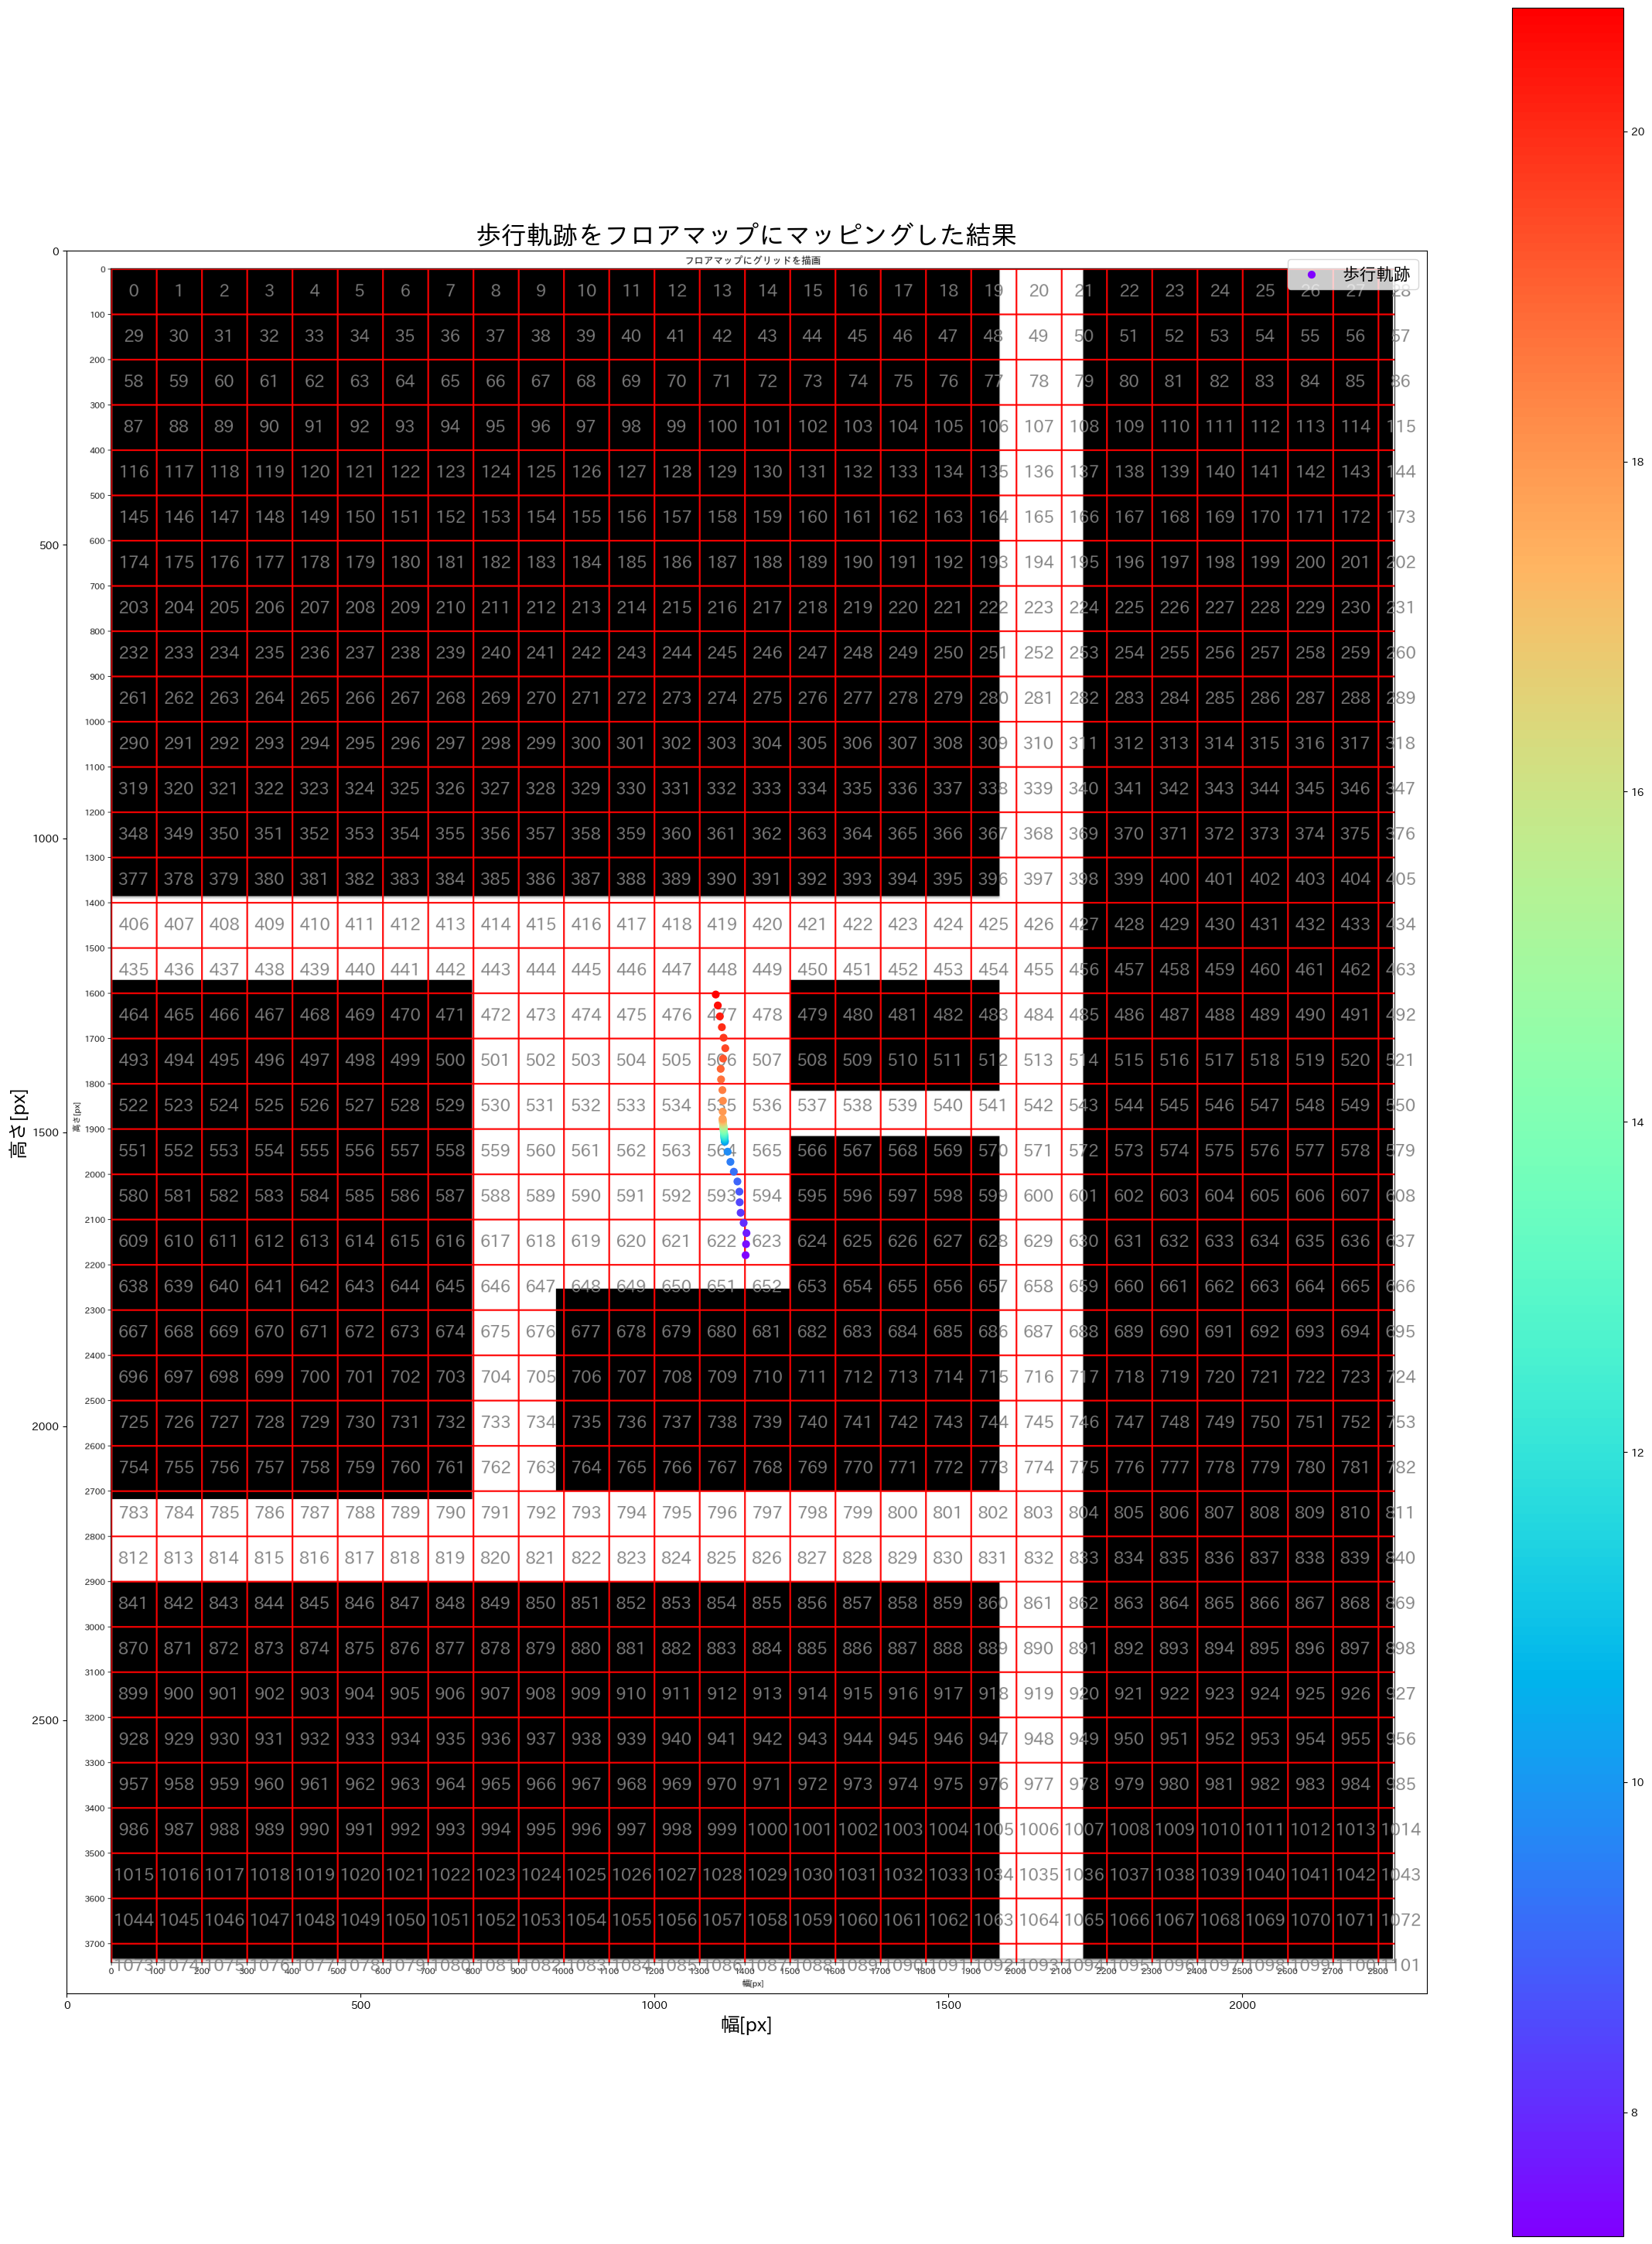

In [170]:
# グリッド付きフロアマップ画像を読み込み
img_grid = Image.open("output/gridFloorMap.png")

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img_grid)

# 変換後の軌跡をプロット
plt.colorbar(plt.scatter(df_trajectory['x_final'], df_trajectory['y_final'],c=time,cmap='rainbow',s=40, label=f'歩行軌跡', zorder=2))

# グラフの装飾
plt.title('歩行軌跡をフロアマップにマッピングした結果', fontsize=24)
plt.xlabel('幅[px]', fontsize=18)
plt.ylabel('高さ[px]', fontsize=18)
plt.legend(fontsize=16)
plt.show()


     time         x         y     speed   stay   x_scaled    y_scaled  \
0    7.25 -0.051118  0.411710       NaN  False  -5.111838   41.171019   
1    7.50 -0.058507  0.599842  0.753107  False  -5.850730   59.984178   
2    7.75 -0.065896  0.787973  0.753107  False  -6.589622   78.797337   
3    8.00 -0.017568  0.961232  0.719489  False  -1.756849   96.123180   
4    8.25  0.033400  1.133785  0.719694  False   3.340016  113.378525   
5    8.50  0.050284  1.312206  0.716873  False   5.028430  131.220631   
6    8.75  0.054663  1.492780  0.722508  False   5.466269  149.278021   
7    9.00  0.088399  1.665715  0.704780  False   8.839922  166.571532   
8    9.25  0.149555  1.831516  0.706880  False  14.955534  183.151604   
9    9.50  0.207363  1.999262  0.709709  False  20.736316  199.926181   
10   9.75  0.255316  2.172732  0.719905  False  25.531638  217.273222   
11  10.00  0.301818  2.341204  0.699085  False  30.181789  234.120360   
12  10.25  0.303077  2.353879  0.050950   True  30.

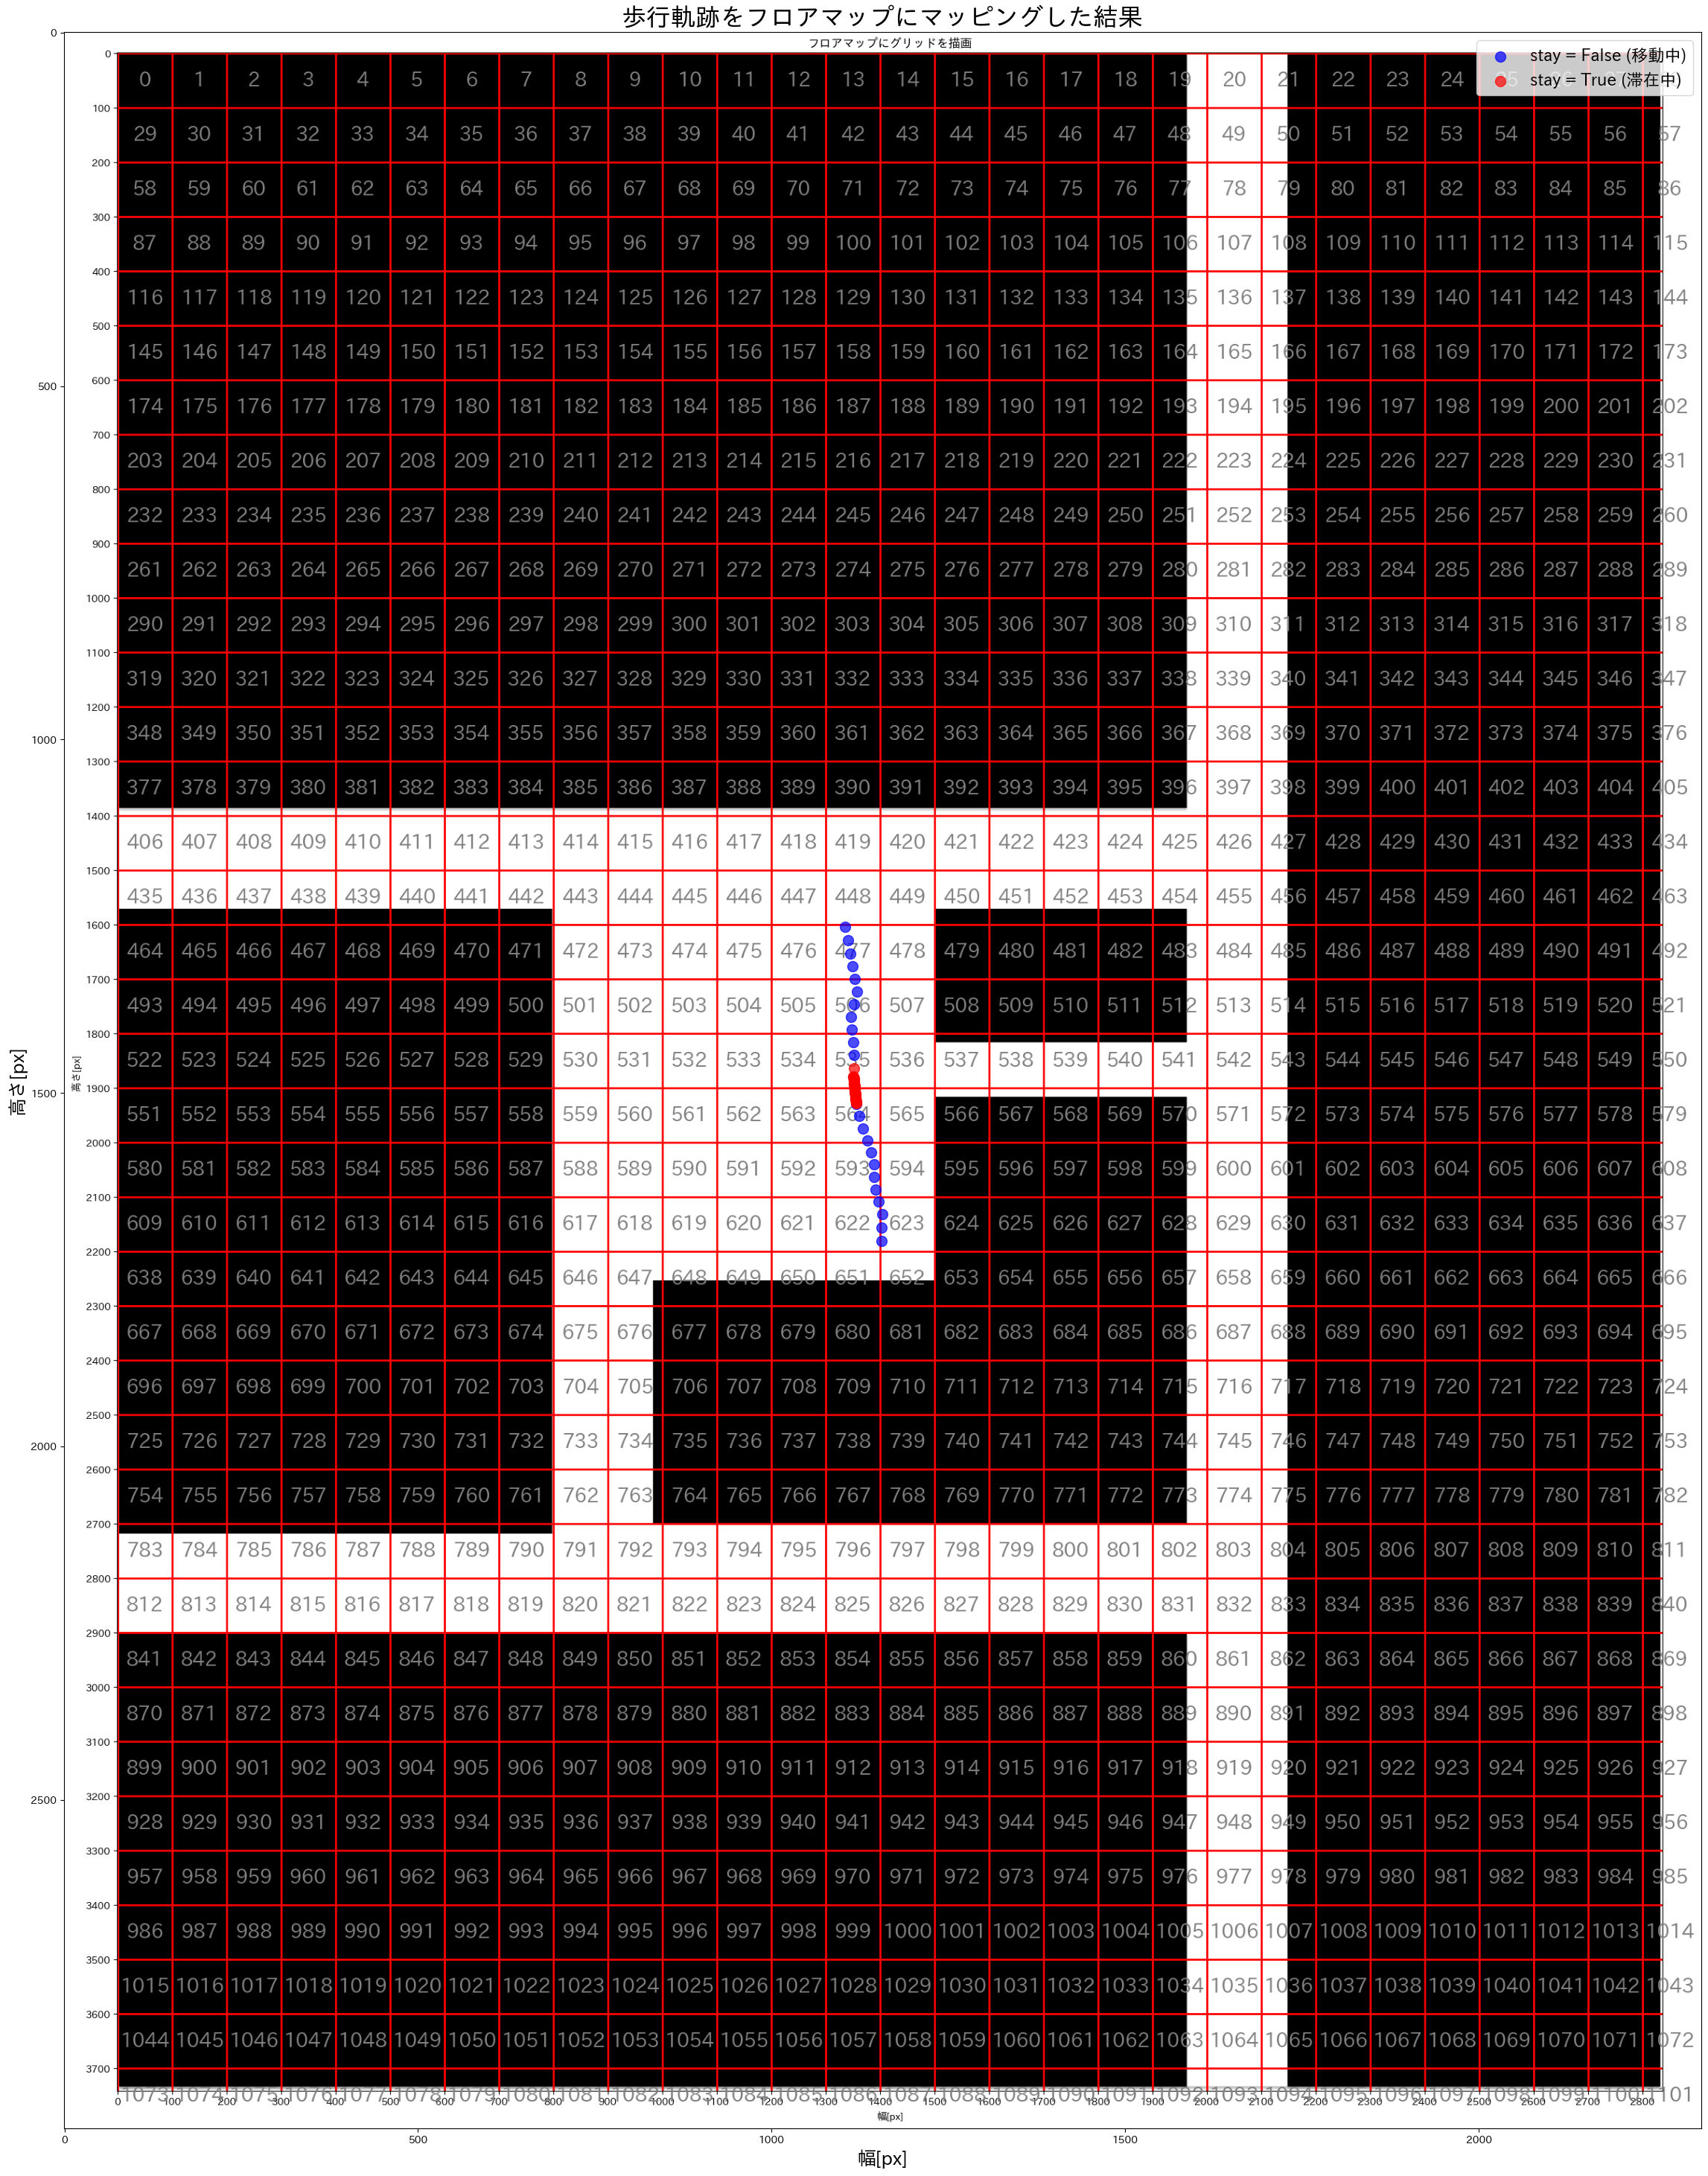

In [ ]:
print(df_trajectory)

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img_grid)

# --- 最終的なプロット ---
# 'stay'列を保持したままのデータフレームをフィルタリング
stay_true_final = df_trajectory[df_trajectory['stay'] == True]
stay_false_final = df_trajectory[df_trajectory['stay'] == False]

# 最終的な座標(x_final, y_final)を使い、stayの値で色分けしてプロット
ax.scatter(stay_false_final['x_final'], stay_false_final['y_final'], 
           c='blue', s=100, label='stay = False (移動中)', zorder=2, alpha=0.7)
ax.scatter(stay_true_final['x_final'], stay_true_final['y_final'], 
           c='red', s=100, label='stay = True (滞在中)', zorder=3, alpha=0.7)
# グラフの装飾
ax.set_title('歩行軌跡をフロアマップにマッピングした結果', fontsize=24)
ax.set_xlabel('幅[px]', fontsize=18)
ax.set_ylabel('高さ[px]', fontsize=18)
ax.legend(fontsize=16)
plt.show()

# 滞在時間の集計


In [ ]:
# diff()で前後の行との差を計算し、最初の行はNaNになるため0で埋める
df_trajectory['time_diff'] = df_trajectory['time'].diff().fillna(0)


     time         x         y     speed   stay   x_scaled    y_scaled  \
0    7.25 -0.051118  0.411710       NaN  False  -5.111838   41.171019   
1    7.50 -0.058507  0.599842  0.753107  False  -5.850730   59.984178   
2    7.75 -0.065896  0.787973  0.753107  False  -6.589622   78.797337   
3    8.00 -0.017568  0.961232  0.719489  False  -1.756849   96.123180   
4    8.25  0.033400  1.133785  0.719694  False   3.340016  113.378525   
5    8.50  0.050284  1.312206  0.716873  False   5.028430  131.220631   
6    8.75  0.054663  1.492780  0.722508  False   5.466269  149.278021   
7    9.00  0.088399  1.665715  0.704780  False   8.839922  166.571532   
8    9.25  0.149555  1.831516  0.706880  False  14.955534  183.151604   
9    9.50  0.207363  1.999262  0.709709  False  20.736316  199.926181   
10   9.75  0.255316  2.172732  0.719905  False  25.531638  217.273222   
11  10.00  0.301818  2.341204  0.699085  False  30.181789  234.120360   
12  10.25  0.303077  2.353879  0.050950   True  30.

In [133]:
## Step 3-2
def find_grid_id(x, y, grid_size_px, num_grids_x, map_width_px, map_height_px):
    """
    座標(x, y)がどのグリッドIDに属するかを計算する。
    マップ範囲外の場合は-1を返す。
    """
    if not (0 <= x < map_width_px and 0 <= y < map_height_px):
        return -1  # マップの範囲外
    
    # 座標がどのグリッドの列・行に位置するかを計算
    grid_col = int(x // grid_size_px)
    grid_row = int(y // grid_size_px)
    
    # グリッドIDを計算
    grid_id = grid_row * num_grids_x + grid_col
    return grid_id

# データフレームの各行に適用して、新しい'grid_id'列を作成
df_trajectory['grid_id'] = df_trajectory.apply(
    lambda row: find_grid_id(row['x_final'], row['y_final'], grid_size, num_grids_x, map_width, map_height),
    axis=1
)


In [137]:
# 結果の確認
print("--- 軌跡データにグリッドIDと時間差を追加 ---")
print(df_trajectory[['time', 'x_final', 'y_final', 'stay', 'time_diff', 'grid_id']])
print("-" * 20)

--- 軌跡データにグリッドIDと時間差を追加 ---
     time      x_final      y_final   stay  time_diff  grid_id
0    7.25  1155.111838  1708.828981  False       0.00      504
1    7.50  1155.850730  1690.015822  False       0.25      475
2    7.75  1156.589622  1671.202663  False       0.25      475
3    8.00  1151.756849  1653.876820  False       0.25      475
4    8.25  1146.659984  1636.621475  False       0.25      475
5    8.50  1144.971570  1618.779369  False       0.25      475
6    8.75  1144.533731  1600.721979  False       0.25      475
7    9.00  1141.160078  1583.428468  False       0.25      446
8    9.25  1135.044466  1566.848396  False       0.25      446
9    9.50  1129.263684  1550.073819  False       0.25      446
10   9.75  1124.468362  1532.726778  False       0.25      446
11  10.00  1119.818211  1515.879640  False       0.25      446
12  10.25  1119.692340  1514.612127   True       0.25      446
13  10.50  1119.566469  1513.344615   True       0.25      446
14  10.75  1119.440598  151

## Step 3-3: 滞在時間の集計
'stay'がTrueで、かつ有効なグリッドIDを持つデータのみをフィルタリング

In [135]:
# 'stay'がTrueで、かつ有効なグリッドIDを持つデータのみをフィルタリング
stay_points = df_trajectory[(df_trajectory['stay'] == True) & (df_trajectory['grid_id'] != -1)]

# グリッドIDごとに滞在時間('time_diff')を合計
stay_time_per_grid = stay_points.groupby('grid_id')['time_diff'].sum()

# 結果の表示 (滞在時間があったグリッドのみ)
print("--- グリッドごとの滞在時間 ---")
print(stay_time_per_grid[stay_time_per_grid > 0])
print("-" * 20)

--- グリッドごとの滞在時間 ---
grid_id
417    5.0
446    3.0
Name: time_diff, dtype: float64
--------------------


## Step 3-4: 結果の可視化 (ヒートマップ)

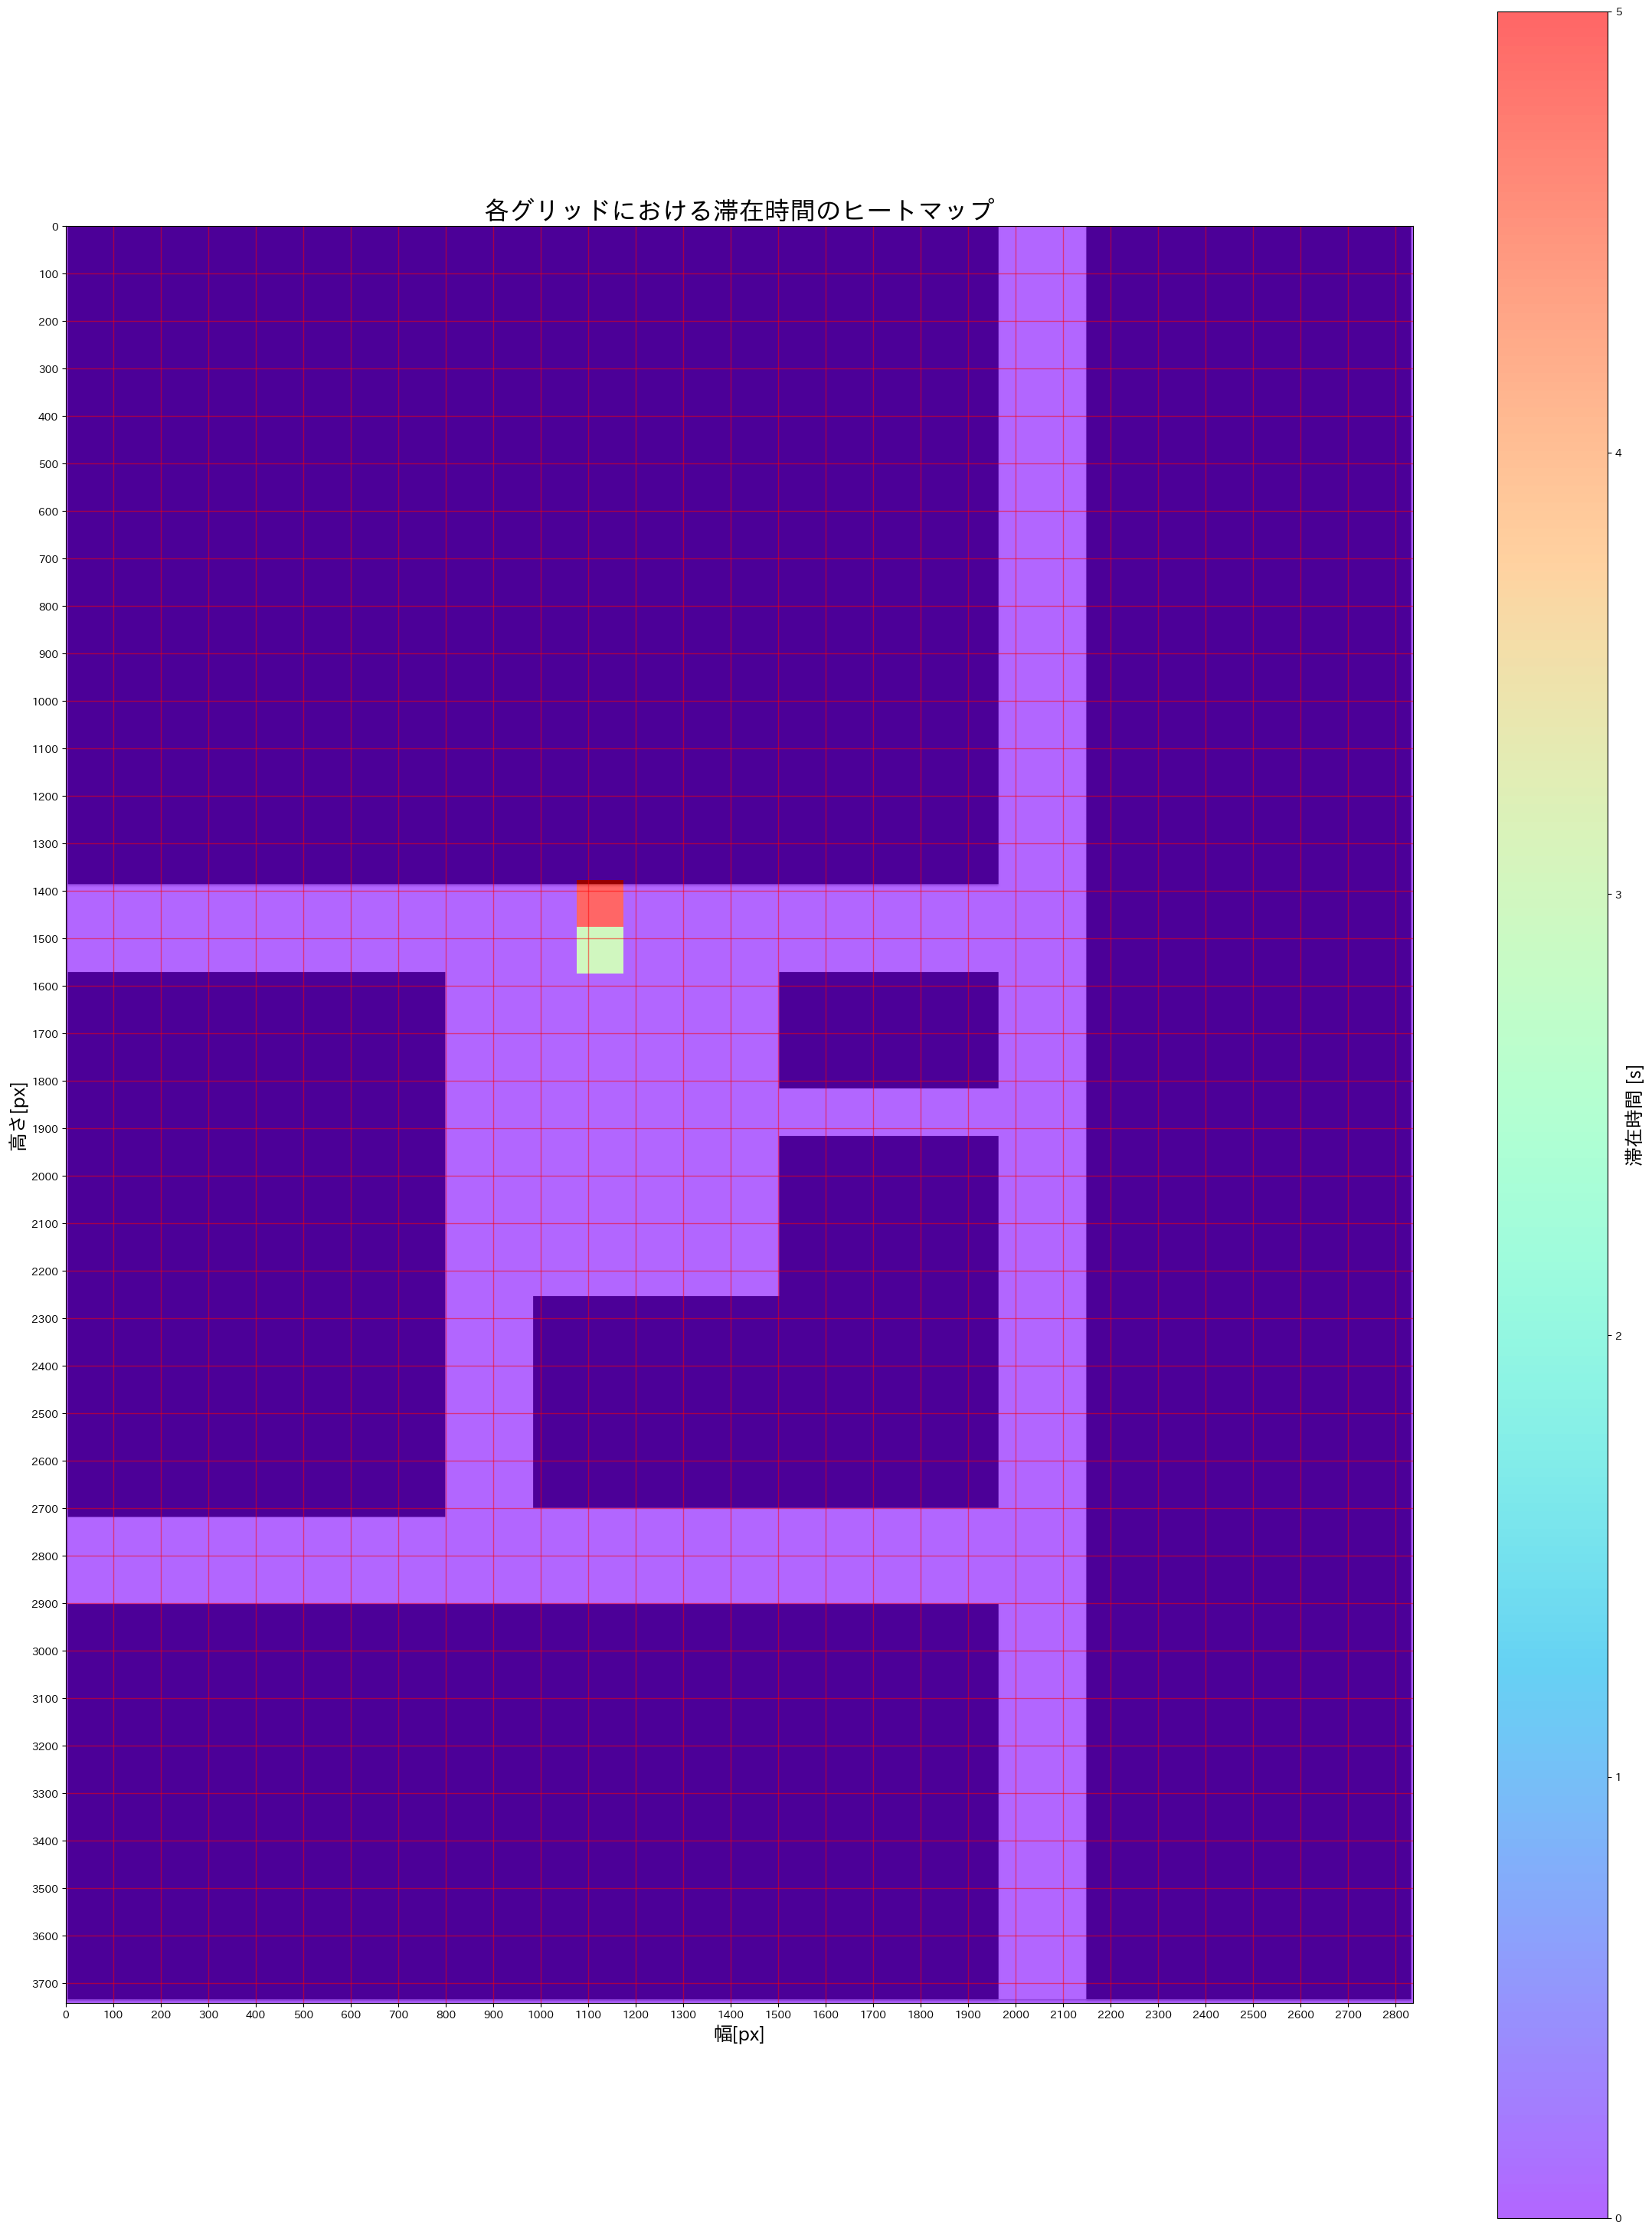

In [172]:
# Step 3-4: 結果の可視化 (ヒートマップ)

# ヒートマップ用のデータを作成 (num_grids_y x num_grids_x の2次元配列)
heatmap_data = np.zeros((num_grids_y, num_grids_x))

# 集計結果をヒートマップデータに反映
for grid_id, total_time in stay_time_per_grid.items():
    # グリッドIDから行と列を計算
    row = int(grid_id // num_grids_x)
    col = int(grid_id % num_grids_x)
    heatmap_data[row, col] = total_time

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)

# フロアマップ画像を描画
ax.imshow(img, extent=[0, map_width, map_height, 0])

# ヒートマップを描画
# extentでヒートマップの描画範囲を画像に合わせる
# alphaで透明度を指定し、下の地図が見えるようにする
# cmapでカラーマップを指定
heatmap = ax.imshow(heatmap_data, cmap='rainbow', alpha=0.6, extent=[0, map_width, map_height, 0])

# カラーバーを追加
cbar = fig.colorbar(heatmap, ax=ax)
cbar.set_label('滞在時間 [s]', fontsize=18)

# グリッド線を描画
ax.set_xticks(np.arange(0, map_width, grid_size))
ax.set_yticks(np.arange(0, map_height, grid_size))
ax.grid(which='both', color='red', linestyle='-', linewidth=1, alpha=0.5)

# グラフの装飾
ax.set_title('各グリッドにおける滞在時間のヒートマップ', fontsize=24)
ax.set_xlabel('幅[px]', fontsize=18)
ax.set_ylabel('高さ[px]', fontsize=18)

# 軸の範囲を画像のサイズに合わせる
ax.set_xlim(0, map_width)
ax.set_ylim(map_height, 0) # y軸の向きを反転

plt.show()
